# Activité 2 : Feature Engineering RFM & Prétraitement sur Online Retail

**Objectifs**
- Nettoyage approfondi des transactions brutes.
- Agrégation par `CustomerID` pour construire le dataset d'analyse RFM (Récence, Fréquence, Montant).
- Traitement de l'asymétrie des données (transformation `np.log1p`) et standardisation des variables.

## 1. Chargement et aperçu des données brutes

In [2]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [4]:
df_raw = pd.read_excel('Online_Retail.xlsx')
print("Dimensions :", df_raw.shape)
df_raw.head()

Dimensions : (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Valeurs manquantes :")
print(df_raw.isnull().sum())
print("\nAnnulations (InvoiceNo commençant par 'C') :", df_raw['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Quantity <= 0 :", (df_raw['Quantity'] <= 0).sum())
print("UnitPrice <= 0 :", (df_raw['UnitPrice'] <= 0).sum())
print("Doublons exacts :", df_raw.duplicated().sum())
print("Clients uniques :", df_raw['CustomerID'].nunique())
print("Période :", df_raw['InvoiceDate'].min(), "->", df_raw['InvoiceDate'].max())

Valeurs manquantes :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Annulations (InvoiceNo commençant par 'C') : 9288
Quantity <= 0 : 10624
UnitPrice <= 0 : 2517
Doublons exacts : 5268
Clients uniques : 4372
Période : 2010-12-01 08:26:00 -> 2011-12-09 12:50:00


**Constats** : une ligne correspond à un article dans une facture (et non à un client). Environ 25 % des lignes n'ont pas de `CustomerID`, et le fichier contient des annulations, des quantités ou prix négatifs ou nuls, et des doublons : un nettoyage est nécessaire avant toute agrégation.

## 2. Nettoyage des transactions

In [6]:
df = df_raw.copy()
etapes = [("Départ", len(df))]

# 1) Lignes sans CustomerID : non rattachables à un client
df = df.dropna(subset=['CustomerID'])
etapes.append(("Sans CustomerID manquant", len(df)))

# 2) Doublons exacts
df = df.drop_duplicates()
etapes.append(("Sans doublons", len(df)))

# 3) Annulations (InvoiceNo commençant par 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
etapes.append(("Sans annulations", len(df)))

# 4) Quantités et prix négatifs ou nuls
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
etapes.append(("Quantité et prix > 0", len(df)))

# 5) Codes qui ne sont pas des produits (frais de port, saisies manuelles...)
df = df[~df['StockCode'].astype(str).isin(['POST', 'M', 'PADS', 'DOT'])]
etapes.append(("Sans codes non-produits", len(df)))

# 6) Types utiles et montant d'une ligne
df['CustomerID'] = df['CustomerID'].astype(int)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

pd.DataFrame(etapes, columns=['Étape', 'Nombre de lignes'])

,Étape,Nombre de lignes
0,Départ,541909
1,Sans CustomerID manquant,406829
2,Sans doublons,401604
3,Sans annulations,392732
4,Quantité et prix > 0,392692
5,Sans codes non-produits,391295


**Justification** : les lignes sans client ne peuvent pas être segmentées ; les annulations, quantités et prix négatifs ou nuls ne sont pas de vrais achats ; les doublons fausseraient la fréquence et le montant. Les codes `POST` et `DOT` (frais de port) et `M` (saisies manuelles) ne sont pas des produits, et `PADS` est une ligne atypique (4 lignes seulement, prix quasi nul). Les annulations ont été supprimées plutôt que déduites des achats, ce qui est plus simple mais écarte les retours de marchandise.

## 3. Agrégation par client : construction du dataset RFM

In [7]:
# Date de référence : le lendemain de la dernière transaction
date_ref = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (date_ref - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("Nombre de clients :", rfm.shape[0])
rfm.describe().round(1)

Nombre de clients : 4335


,CustomerID,Recency,Frequency,Monetary
count,4335.0,4335.0,4335.0,4335.0
mean,15299.4,92.7,4.2,2017.1
std,1721.8,100.2,7.6,8919.4
min,12346.0,1.0,1.0,3.8
25%,13812.5,18.0,1.0,304.2
50%,15298.0,51.0,2.0,663.6
75%,16778.5,143.0,5.0,1631.5
max,18287.0,374.0,206.0,279138.0


**Définition des variables** : `Recency` = nombre de jours depuis le dernier achat (plus elle est faible, plus le client est récent) ; `Frequency` = nombre de factures distinctes ; `Monetary` = montant total dépensé.

## 4. Asymétrie des variables et transformation `log1p`

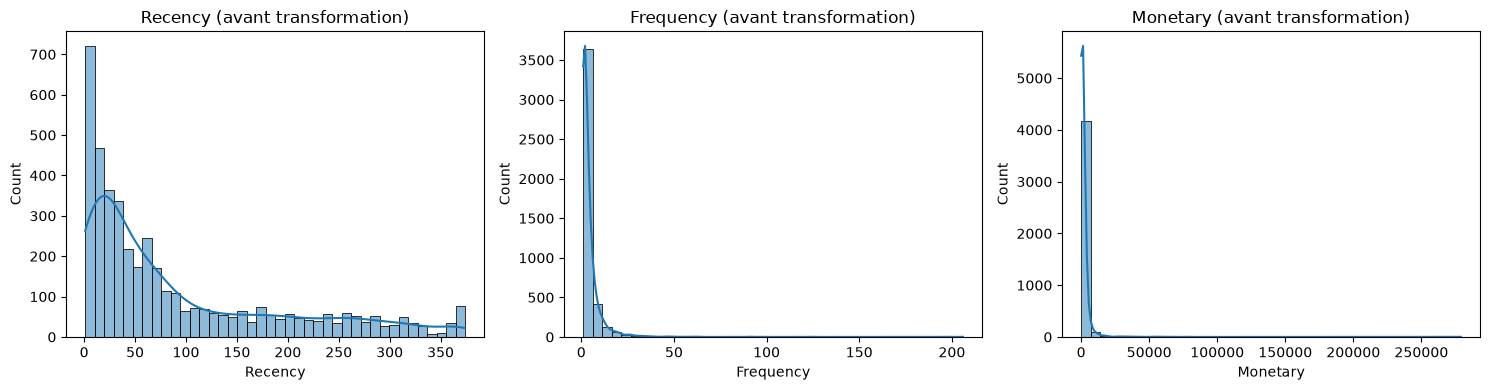

Asymétrie avant :
Recency       1.24
Frequency    11.97
Monetary     19.55
dtype: float64


In [8]:
variables = ['Recency', 'Frequency', 'Monetary']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, variables):
    sns.histplot(rfm[var], bins=40, kde=True, ax=ax)
    ax.set_title(f'{var} (avant transformation)')
plt.tight_layout()
plt.show()

print("Asymétrie avant :")
print(rfm[variables].skew().round(2))

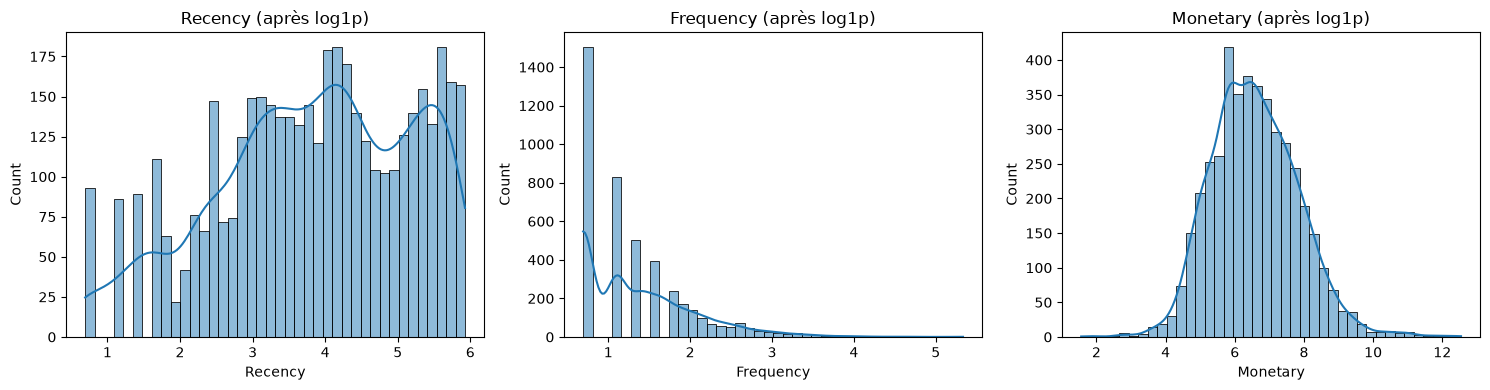

Asymétrie après log1p :
Recency     -0.38
Frequency    1.21
Monetary     0.40
dtype: float64


In [9]:
rfm_log = rfm.copy()
rfm_log[variables] = np.log1p(rfm_log[variables])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, variables):
    sns.histplot(rfm_log[var], bins=40, kde=True, ax=ax)
    ax.set_title(f'{var} (après log1p)')
plt.tight_layout()
plt.show()

print("Asymétrie après log1p :")
print(rfm_log[variables].skew().round(2))

**Interprétation** : avant transformation, la fréquence (asymétrie d'environ 12) et surtout le montant (environ 19,6) sont très asymétriques : quelques clients très actifs dominent. Après `log1p`, les asymétries tombent à environ 1,2 pour la fréquence et 0,4 pour le montant, et la récence devient presque symétrique (environ -0,4). La transformation compresse les grandes valeurs, ce qui évite que K-means soit dominé par les clients extrêmes. On applique `log1p` avant la standardisation, car `log1p` est défini pour toute valeur positive ou nulle.

## 5. Standardisation

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = pd.DataFrame(scaler.fit_transform(rfm_log[variables]), columns=variables)

print("Moyenne et écart-type après standardisation :")
display(rfm_scaled.describe().loc[['mean', 'std']].round(2))
rfm_scaled.head()

Moyenne et écart-type après standardisation :


,Recency,Frequency,Monetary
mean,0.0,0.0,0.0
std,1.0,1.0,1.0


,Recency,Frequency,Monetary
0,1.460165,-0.951420,3.726618
1,-2.037990,1.081712,1.428561
2,0.372077,0.392407,0.554153
3,-0.623381,-0.951420,0.565323
4,1.422757,-0.951420,-0.706655


**Vérification** : chaque variable a une moyenne de 0 et un écart-type de 1, donc aucune ne domine le calcul des distances. Le jeu de données `rfm_scaled` (4 335 clients, 3 variables) est prêt pour le clustering ; `rfm` conserve les valeurs d'origine pour interpréter les clusters en jours, en commandes et en livres sterling. Après `log1p`, la fréquence et le montant sont fortement corrélés (environ 0,81), point à garder en tête pour l'interprétation.

In [11]:
print("Corrélations (après log1p) :")
rfm_log[variables].corr().round(2)

Corrélations (après log1p) :


,Recency,Frequency,Monetary
Recency,1.00,-0.57,-0.49
Frequency,-0.57,1.00,0.81
Monetary,-0.49,0.81,1.00


## 6. Analyses complémentaires

Cinq questions pour justifier le prétraitement, vérifier les variables RFM et comprendre les segments de clients. Les cellules doivent être exécutées dans l'ordre : la question 5 crée la colonne `Cluster` dans `rfm`.

### Question 1 : pourquoi faut-il transformer les variables avec `log1p` ?

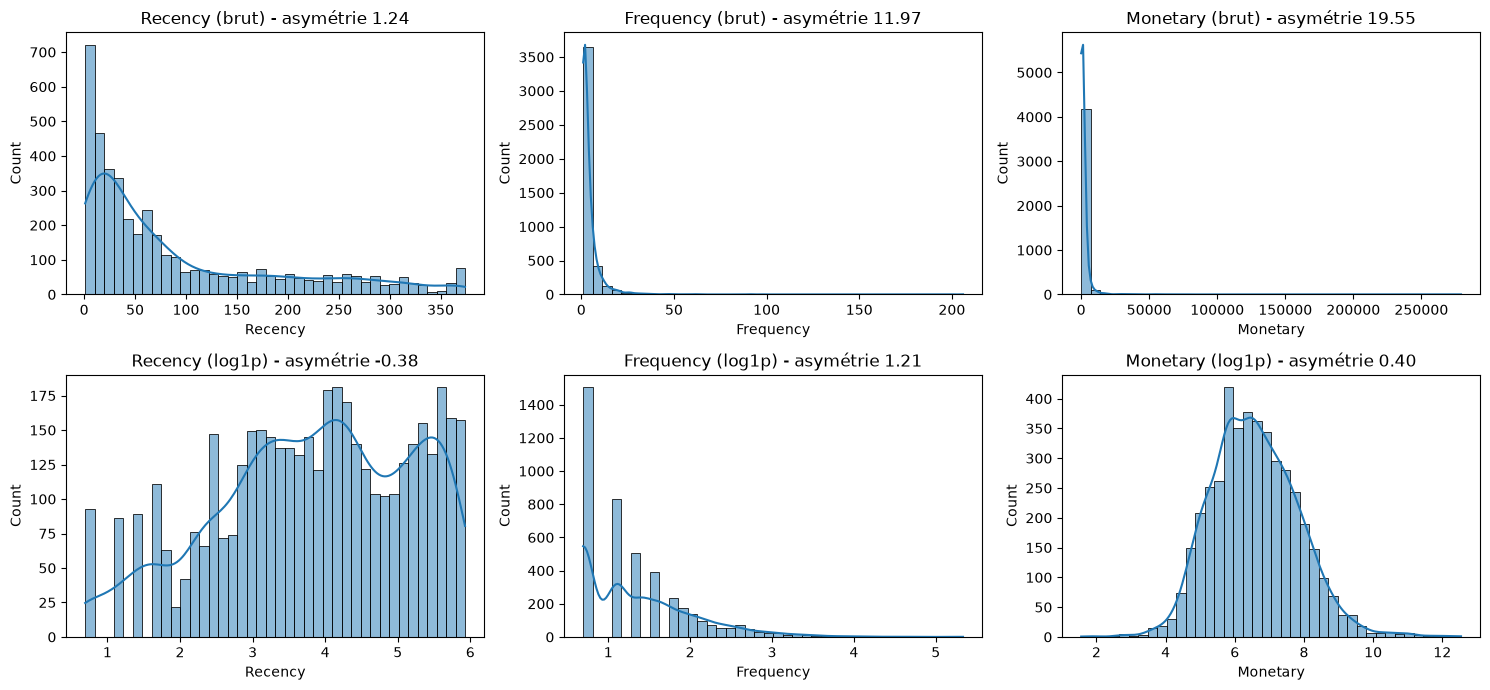

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for j, var in enumerate(variables):
    sns.histplot(rfm[var], bins=40, kde=True, ax=axes[0, j])
    axes[0, j].set_title(f'{var} (brut) - asymétrie {rfm[var].skew():.2f}')
    sns.histplot(rfm_log[var], bins=40, kde=True, ax=axes[1, j])
    axes[1, j].set_title(f'{var} (log1p) - asymétrie {rfm_log[var].skew():.2f}')
plt.tight_layout()
plt.show()

**Commentaire :** ce graphique compare les distributions avant (ligne du haut) et après (ligne du bas) la transformation `log1p`. Nous voulons démontrer que la fréquence et surtout le montant sont très asymétriques : la plupart des clients dépensent peu, et quelques-uns dépensent énormément (asymétries d'environ 12 et 19,6). Sans transformation, ces valeurs extrêmes domineraient le calcul des distances et fausseraient K-means. Après `log1p`, les distributions sont beaucoup plus équilibrées (asymétries d'environ 1,2 et 0,4), ce qui justifie cette étape de prétraitement.

### Question 2 : les trois variables RFM apportent-elles des informations différentes ?

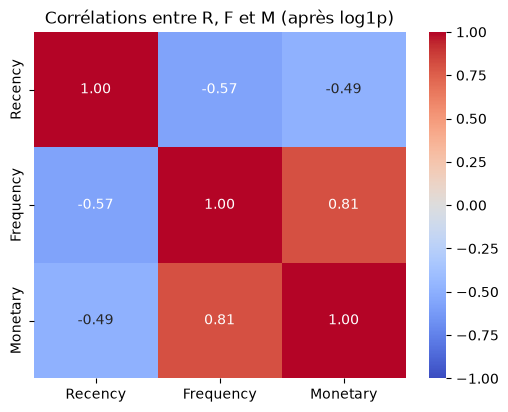

In [13]:
plt.figure(figsize=(6, 4.5))
sns.heatmap(rfm_log[variables].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Corrélations entre R, F et M (après log1p)')
plt.show()

**Commentaire :** nous cherchons à savoir si certaines variables sont redondantes avant le clustering. La fréquence et le montant sont fortement corrélés (environ 0,81) : un client qui commande souvent dépense logiquement davantage. La récence est corrélée négativement aux deux (environ -0,57 et -0,49) : les clients récents sont aussi les plus actifs. La fréquence et le montant portent donc en partie la même information, ce qu'il faudra garder en tête pour interpréter les clusters. Nous conservons néanmoins les trois variables, car elles décrivent trois dimensions complémentaires du comportement d'achat.

### Question 3 : le chiffre d'affaires dépend-il d'un petit nombre de clients ?

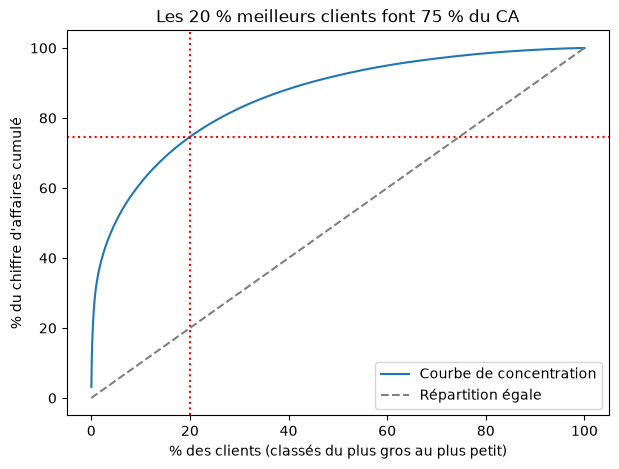

In [14]:
ca = rfm.sort_values('Monetary', ascending=False)['Monetary'].reset_index(drop=True)
part_clients = (np.arange(1, len(ca) + 1) / len(ca)) * 100
part_ca = ca.cumsum() / ca.sum() * 100
top20 = part_ca[int(0.2 * len(ca)) - 1]

plt.figure(figsize=(7, 5))
plt.plot(part_clients, part_ca, label='Courbe de concentration')
plt.plot([0, 100], [0, 100], '--', color='grey', label='Répartition égale')
plt.axvline(20, color='red', linestyle=':')
plt.axhline(top20, color='red', linestyle=':')
plt.xlabel('% des clients (classés du plus gros au plus petit)')
plt.ylabel("% du chiffre d'affaires cumulé")
plt.title(f'Les 20 % meilleurs clients font {top20:.0f} % du CA')
plt.legend()
plt.show()

**Commentaire :** cette courbe de concentration (type Pareto) montre quelle part du chiffre d'affaires est générée par les meilleurs clients. Plus la courbe s'éloigne de la diagonale (répartition égale), plus l'activité est concentrée. Ici, les 20 % meilleurs clients génèrent environ 75 % du chiffre d'affaires. Nous voulons démontrer que tous les clients n'ont pas la même valeur, ce qui justifie la segmentation : les actions marketing doivent être différentes selon les groupes, avec une attention particulière aux meilleurs clients.

### Question 4 : combien de segments de clients distincts existe-t-il ?

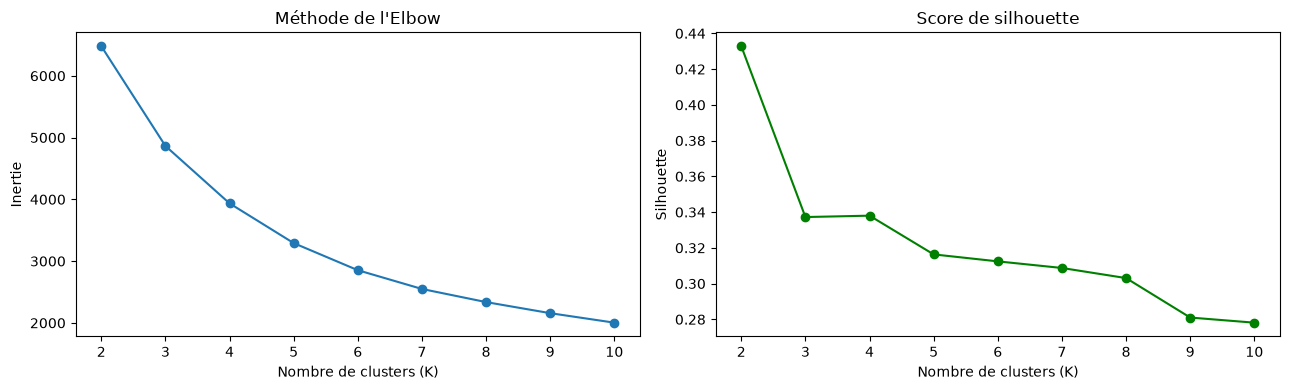

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(rfm_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(ks), inertias, marker='o')
axes[0].set_title("Méthode de l'Elbow")
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')
axes[1].plot(list(ks), sils, marker='o', color='green')
axes[1].set_title('Score de silhouette')
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

**Commentaire :** nous cherchons le nombre de clusters à retenir avec deux critères complémentaires : l'inertie (le coude de la courbe) et le score de silhouette (qualité de la séparation des clusters). Ici, le coude est progressif et peu net. La silhouette est la plus élevée pour K = 2 (environ 0,43), mais cette solution sépare seulement les clients actifs des clients inactifs, ce qui est trop grossier pour un usage marketing. Pour K = 3 ou 4, elle reste d'environ 0,34. Nous retenons donc K = 4, un compromis entre qualité statistique et segments interprétables.

### Question 5 : quels sont les profils des clusters et leur poids économique ?

,Recency,Frequency,Monetary,Effectif,% CA
Cluster,,,,,
0,18.3,2.1,532.9,835,5.1
1,182.9,1.3,349.0,1628,6.5
2,68.3,4.1,1790.1,1182,24.2
3,11.8,13.9,8137.8,690,64.2


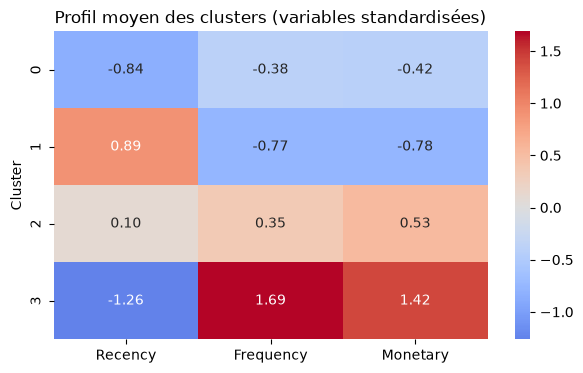

In [16]:
K = 4
km = KMeans(n_clusters=K, random_state=0, n_init=10).fit(rfm_scaled)
rfm['Cluster'] = km.labels_

# Profils en valeurs d'origine
profils = rfm.groupby('Cluster')[variables].mean().round(1)
profils['Effectif'] = rfm['Cluster'].value_counts().sort_index()
profils['% CA'] = (rfm.groupby('Cluster')['Monetary'].sum() / rfm['Monetary'].sum() * 100).round(1)
display(profils)

# Heatmap des profils (variables standardisées)
z = rfm_scaled.copy()
z['Cluster'] = rfm['Cluster']
plt.figure(figsize=(7, 4))
sns.heatmap(z.groupby('Cluster')[variables].mean(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Profil moyen des clusters (variables standardisées)')
plt.show()

**Commentaire :** la heatmap montre, pour chaque cluster, si ses clients sont au-dessus (rouge) ou en dessous (bleu) de la moyenne sur chaque variable, ce qui permet de nommer les segments. Nous obtenons quatre profils : les **meilleurs clients** (environ 690 clients, récents, environ 14 commandes, 8 138 £ en moyenne), qui font environ 64 % du chiffre d'affaires ; les **clients réguliers** (environ 1 180 clients, environ 24 % du CA) ; les **clients récents peu actifs** (environ 835 clients, acheteurs récents mais avec peu de commandes) ; et les **clients perdus** (environ 1 630 clients, dernier achat il y a environ 183 jours, seulement 6,5 % du CA). Nous voulons démontrer que chaque segment appelle une action marketing différente : fidéliser les meilleurs clients, développer les réguliers, activer les nouveaux et relancer les inactifs.

## 7. Clustering K-means

Cette section applique l'algorithme K-means aux données RFM standardisées (`rfm_scaled`), avec le nombre de clusters retenu à la question 4 (K = 4). Nous décrivons ensuite les segments, les visualisons, mesurons leur poids économique et vérifions la stabilité du modèle. Nous comparons enfin K-means à un second algorithme (clustering hiérarchique), puis nous définissons les personas marketing à partir des moyennes et médianes de chaque segment.

### 7.1 Application de K-means

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K = 4
kmeans = KMeans(n_clusters=K, random_state=0, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm['Cluster'].value_counts().sort_index())
print("Inertie :", round(kmeans.inertia_, 1))
print("Silhouette :", round(silhouette_score(rfm_scaled, rfm['Cluster']), 3))

Cluster
0     835
1    1628
2    1182
3     690
Name: count, dtype: int64
Inertie : 3935.0
Silhouette : 0.338


**Commentaire :** nous appliquons K-means avec K = 4 sur les données RFM standardisées. `n_init=10` relance l'algorithme avec 10 initialisations et garde la meilleure, et `random_state=0` rend le résultat reproductible. Chaque client reçoit un numéro de cluster. Les clusters comptent environ 835, 1 628, 1 182 et 690 clients. La silhouette (environ 0,34) indique une séparation correcte mais pas très marquée, ce qui est fréquent pour des données de comportement client, où les segments se touchent.

### 7.2 Description des segments

In [18]:
profils = rfm.groupby('Cluster')[variables].mean()

# Les numéros de cluster sont arbitraires : on nomme les segments d'après leur profil
noms = {}
noms[profils['Monetary'].idxmax()] = 'Meilleurs clients'
noms[profils['Recency'].idxmax()] = 'Clients perdus'
restants = sorted([c for c in profils.index if c not in noms], key=lambda c: profils.loc[c, 'Monetary'])
noms[restants[0]] = 'Récents peu actifs'
noms[restants[1]] = 'Clients réguliers'
rfm['Segment'] = rfm['Cluster'].map(noms)

resume = rfm.groupby('Segment').agg(
    Clients=('CustomerID', 'count'),
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    CA_total=('Monetary', 'sum')
).round(1)
resume['% clients'] = (resume['Clients'] / resume['Clients'].sum() * 100).round(1)
resume['% CA'] = (resume['CA_total'] / resume['CA_total'].sum() * 100).round(1)
resume

,Clients,Recency,Frequency,Monetary,CA_total,% clients,% CA
Segment,,,,,,,
Clients perdus,1628,182.9,1.3,349.0,568199.8,37.6,6.5
Clients réguliers,1182,68.3,4.1,1790.1,2115839.9,27.3,24.2
Meilleurs clients,690,11.8,13.9,8137.8,5615102.2,15.9,64.2
Récents peu actifs,835,18.3,2.1,532.9,444936.7,19.3,5.1


**Commentaire :** ce tableau décrit chaque segment en valeurs d'origine (jours, commandes, livres sterling). Les **meilleurs clients** sont récents (environ 12 jours), commandent souvent (environ 14 fois) et dépensent en moyenne environ 8 138 £. Les **clients réguliers** ont un dernier achat vieux d'environ 68 jours et environ 4 commandes. Les **récents peu actifs** ont acheté récemment (environ 18 jours) mais seulement environ 2 fois. Les **clients perdus** n'ont pas acheté depuis environ 183 jours et seulement environ 1,3 fois. Les noms sont attribués d'après les profils, pas d'après les numéros de cluster, donc ils restent corrects si les numéros changent.

### 7.3 Visualisation des segments (PCA 2D)

Variance expliquée : [0.751 0.187] | totale : 0.938


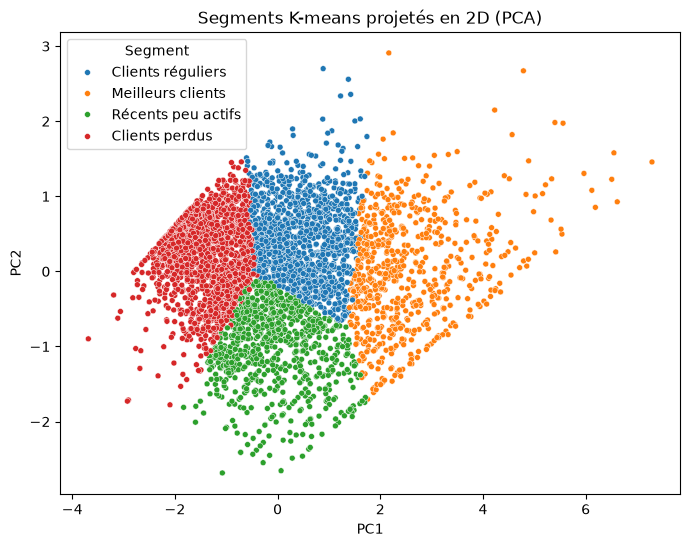

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(rfm_scaled)
rfm['PC1'], rfm['PC2'] = coords[:, 0], coords[:, 1]
print("Variance expliquée :", pca.explained_variance_ratio_.round(3), "| totale :", round(pca.explained_variance_ratio_.sum(), 3))

plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm, x='PC1', y='PC2', hue='Segment', palette='tab10', s=18)
plt.title('Segments K-means projetés en 2D (PCA)')
plt.show()

**Commentaire :** les données RFM ont trois dimensions, donc nous les projetons sur un plan avec la PCA. Les deux premières composantes conservent environ 94 % de la variance, donc la projection est fidèle. La première composante combine fréquence et montant (positifs) et récence (négatif) : elle mesure l'activité du client. La seconde correspond surtout à la récence. Les segments sont bien ordonnés dans le plan, mais ils forment un nuage continu avec des frontières voisines, sans zones vides entre eux. Cela signifie que K-means découpe un continuum de comportements plutôt que de séparer des groupes naturellement isolés.

### 7.4 Poids économique des segments

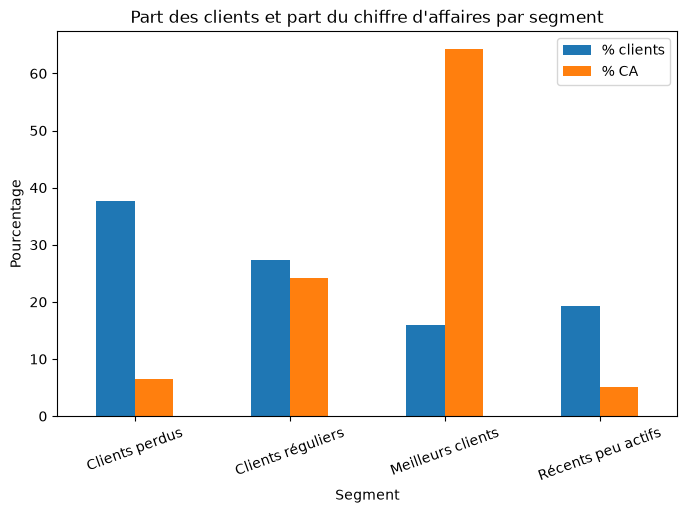

In [20]:
resume[['% clients', '% CA']].plot(kind='bar', figsize=(8, 5))
plt.ylabel('Pourcentage')
plt.title("Part des clients et part du chiffre d'affaires par segment")
plt.xticks(rotation=20)
plt.show()

**Commentaire :** ce graphique compare le poids de chaque segment en nombre de clients et en chiffre d'affaires. Les meilleurs clients représentent environ 16 % de la base mais environ 64 % du chiffre d'affaires, alors que les clients perdus représentent environ 38 % de la base pour seulement 6,5 % du chiffre d'affaires. Nous voulons montrer que la valeur est très concentrée, ce qui justifie des actions différenciées : fidéliser les meilleurs clients, développer les réguliers, activer les récents peu actifs et relancer les inactifs.

### 7.5 Stabilité du modèle

In [21]:
from sklearn.metrics import adjusted_rand_score

aris = []
for seed in [1, 2, 3, 4, 5]:
    labels = KMeans(n_clusters=K, random_state=seed, n_init=10).fit_predict(rfm_scaled)
    aris.append(round(adjusted_rand_score(rfm['Cluster'], labels), 3))
print("Indice de Rand ajusté entre le modèle de référence et 5 autres initialisations :", aris)

Indice de Rand ajusté entre le modèle de référence et 5 autres initialisations : [0.997, 0.97, 0.953, 0.997, 0.951]


**Commentaire :** K-means dépend de l'initialisation des centres, donc nous vérifions que les segments ne changent pas d'une exécution à l'autre. L'indice de Rand ajusté vaut 1 quand deux partitions sont identiques. Avec cinq autres initialisations, il reste au moins d'environ 0,95 : les segments sont donc stables et ne dépendent pas du hasard.

### 7.6 Comparaison avec le clustering hiérarchique

In [22]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

hier = AgglomerativeClustering(n_clusters=K, linkage='ward')
rfm['Cluster_Hier'] = hier.fit_predict(rfm_scaled)

print("Silhouette K-means :", round(silhouette_score(rfm_scaled, rfm['Cluster']), 3))
print("Silhouette hiérarchique :", round(silhouette_score(rfm_scaled, rfm['Cluster_Hier']), 3))
print("Indice de Rand ajusté :", round(adjusted_rand_score(rfm['Cluster'], rfm['Cluster_Hier']), 2))
pd.crosstab(rfm['Segment'], rfm['Cluster_Hier'])

Silhouette K-means : 0.338
Silhouette hiérarchique : 0.255
Indice de Rand ajusté : 0.41


Cluster_Hier,0,1,2,3
Segment,,,,
Clients perdus,0,1132,0,496
Clients réguliers,79,141,680,282
Meilleurs clients,629,0,61,0
Récents peu actifs,2,0,247,586


**Commentaire :** nous comparons K-means à un second algorithme, le clustering hiérarchique (critère de Ward), avec le même nombre de clusters. Le score de silhouette est plus faible pour le clustering hiérarchique (environ 0,26 contre 0,34) et l'accord entre les deux partitions n'est que partiel (indice de Rand ajusté d'environ 0,41). Les données RFM forment un continuum sans groupes naturellement isolés, donc les deux méthodes découpent cet espace différemment. Nous retenons K-means, qui sépare mieux les clusters et dont les profils sont plus faciles à interpréter.

### 7.7 Moyennes et médianes par segment

In [23]:
ordre = ['Meilleurs clients', 'Clients réguliers', 'Récents peu actifs', 'Clients perdus']
stats = rfm.groupby('Segment')[variables].agg(['mean', 'median']).round(1).loc[ordre]
stats

Recency        Frequency        Monetary        
                      mean median      mean median     mean  median
Segment                                                            
Meilleurs clients     11.8    8.0      13.9   10.0   8137.8  3715.4
Clients réguliers     68.3   53.0       4.1    4.0   1790.1  1345.0
Récents peu actifs    18.3   17.0       2.1    2.0    532.9   457.7
Clients perdus       182.9  177.0       1.3    1.0    349.0   298.2

**Commentaire :** pour la plupart des segments, la moyenne et la médiane sont proches. Pour les meilleurs clients, elles diffèrent beaucoup : le montant moyen est d'environ 8 138 £ contre une médiane d'environ 3 715 £, et la fréquence moyenne d'environ 13,9 contre une médiane de 10. Quelques très gros clients tirent la moyenne vers le haut, donc la médiane décrit mieux le client typique du segment. Nous nous appuyons donc sur les médianes pour définir les personas.

### 7.8 Personas marketing de GlobalShop Direct

In [24]:
personas = pd.DataFrame({
    'Segment': ordre,
    'Persona': ['Les Fidèles VIP', 'Les Réguliers', 'Les Nouveaux à activer', 'Les Endormis'],
    'Profil': [
        'Achètent très souvent, récemment et pour des montants élevés',
        'Achètent régulièrement, avec un dernier achat de quelques semaines',
        'Ont acheté récemment mais ne sont revenus que peu de fois',
        "N'ont pas acheté depuis plusieurs mois, souvent une seule commande"
    ],
    'Action marketing': [
        'Programme VIP, avantages exclusifs, accès anticipé aux nouveautés',
        'Offres de montée en gamme et recommandations personnalisées',
        "Email de bienvenue, offre sur la 2e ou 3e commande pour installer l'habitude",
        'Campagne de réactivation avec remise ciblée, avant de les considérer comme perdus'
    ]
})
personas

,Segment,Persona,Profil,Action marketing
0,Meilleurs clients,Les Fidèles VIP,"Achètent très souvent, récemment et pour des m...","Programme VIP, avantages exclusifs, accès anti..."
1,Clients réguliers,Les Réguliers,"Achètent régulièrement, avec un dernier achat ...",Offres de montée en gamme et recommandations p...
2,Récents peu actifs,Les Nouveaux à activer,Ont acheté récemment mais ne sont revenus que ...,"Email de bienvenue, offre sur la 2e ou 3e comm..."
3,Clients perdus,Les Endormis,"N'ont pas acheté depuis plusieurs mois, souven...","Campagne de réactivation avec remise ciblée, a..."


**Commentaire :** ce tableau définit, pour chaque segment, un persona marketing de GlobalShop Direct à partir des médianes. Les **Fidèles VIP** (médianes : dernier achat il y a environ 8 jours, 10 commandes, environ 3 715 £) font environ 64 % du chiffre d'affaires avec environ 16 % des clients : il faut les fidéliser en priorité. Les **Réguliers** (environ 53 jours, 4 commandes, environ 1 345 £) ont un potentiel de montée en gamme. Les **Nouveaux à activer** (environ 17 jours, 2 commandes, environ 458 £) doivent être incités à revenir. Les **Endormis** (environ 177 jours, 1 commande, environ 298 £) représentent environ 38 % des clients mais seulement 6,5 % du chiffre d'affaires, donc leur réactivation doit rester peu coûteuse.

## Conclusion

- **Nettoyage** : de 541 909 lignes brutes, il reste 391 295 transactions valides, rattachées à 4 335 clients.
- **Dataset RFM** : chaque client est décrit par sa récence, sa fréquence et son montant. Ces variables étant très asymétriques (surtout la fréquence et le montant), nous les avons transformées avec `log1p`, puis standardisées pour qu'aucune ne domine le calcul des distances.
- **Concentration** : les 20 % meilleurs clients génèrent environ 75 % du chiffre d'affaires.
- **Choix du modèle** : la méthode du coude est peu marquée et la silhouette est la plus élevée pour K = 2, solution trop grossière pour un usage marketing. Nous retenons K = 4 avec K-means (silhouette d'environ 0,34). Le clustering hiérarchique donne une silhouette plus faible (environ 0,26) et une partition seulement en partie similaire (indice de Rand ajusté d'environ 0,41), ce qui confirme le choix de K-means.
- **Validation** : les segments sont stables d'une initialisation à l'autre (indice de Rand ajusté d'au moins 0,95 environ), et la projection PCA (environ 94 % de variance conservée) confirme leur organisation selon l'activité et la récence des clients.
- **Segments et personas** : les moyennes et médianes par segment définissent quatre personas pour GlobalShop Direct : les Fidèles VIP, les Réguliers, les Nouveaux à activer et les Endormis. Les médianes sont plus fiables que les moyennes, surtout pour les meilleurs clients, dont le montant moyen (environ 8 138 £) est plus du double de la médiane (environ 3 715 £).
- **Poids économique** : les Fidèles VIP (environ 16 % de la base) font environ 64 % du chiffre d'affaires, alors que les Endormis (environ 38 % de la base) n'en font que 6,5 %. Les actions marketing doivent donc être différenciées : fidéliser les VIP, développer les réguliers, activer les nouveaux et réactiver les endormis à faible coût.
- **Limites** : le choix de K = 4 repose en partie sur l'interprétabilité des segments. Les segments forment un continuum plutôt que des groupes isolés. Les annulations ont été supprimées au lieu d'être déduites des achats.